# Customer Segmentation & Sales Analytics for an Online Retail Business

**Author:** Vibhu
**Project Type:** Data Analytics (Medium Difficulty)
**Domain:** E-Commerce / Retail Analytics

## Objective
Analyze an online retail store's transaction history to:
1. Clean and explore raw transactional data
2. Uncover sales trends (time, geography, products)
3. Engineer RFM (Recency, Frequency, Monetary) features per customer
4. Segment customers using K-Means clustering
5. Profile each segment and derive actionable business recommendations
6. Build a simple short-term revenue forecast

## Dataset
This notebook works with data shaped exactly like the widely-used **UCI "Online Retail II"** dataset
(invoice-level transactions for a UK-based online gift retailer, 2009-2011).

- If a file named `online_retail.csv` is present in the working directory, it will be loaded and used.
- Otherwise, the notebook **generates a realistic synthetic dataset** with the same schema and
  statistical characteristics (seasonality, repeat customers, cancellations, a Pareto-like sales
  distribution) so the whole pipeline below is fully reproducible without an internet connection.

Real dataset link (for reference / optional substitution):
UCI Machine Learning Repository — Online Retail II: https://archive.ics.uci.edu/dataset/502/online+retail+ii
(also mirrored on Kaggle: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

Schema used (matches the real dataset):

| Column | Description |
|---|---|
| InvoiceNo | Unique invoice number (prefixed 'C' = cancellation) |
| StockCode | Product code |
| Description | Product name |
| Quantity | Units purchased |
| InvoiceDate | Date/time of the transaction |
| UnitPrice | Price per unit (in GBP) |
| CustomerID | Unique customer identifier |
| Country | Customer's country |


In [1]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Data Loading

We first check for a real dataset file. If it isn't present, we generate a synthetic dataset with
the same structure, realistic seasonality, a Pareto-like distribution of spend across customers, and
a small fraction of cancelled orders (invoice numbers starting with 'C'), just like the real
Online Retail II dataset.

In [2]:

import os

DATA_PATH = "online_retail.csv"

def generate_synthetic_retail_data(n_customers=800, n_days=365 * 2, seed=RANDOM_SEED):
    """Generates a synthetic e-commerce transactions dataset shaped like
    the UCI Online Retail II dataset."""
    rng = np.random.default_rng(seed)

    countries = (["United Kingdom"] * 70 + ["Germany"] * 8 + ["France"] * 7 +
                 ["Ireland"] * 5 + ["Spain"] * 4 + ["Netherlands"] * 3 +
                 ["Belgium"] * 3)

    products = [
        ("85123A", "WHITE HANGING HEART T-LIGHT HOLDER", 2.55),
        ("71053", "WHITE METAL LANTERN", 3.39),
        ("84406B", "CREAM CUPID HEARTS COAT HANGER", 2.75),
        ("21730", "GLASS STAR FROSTED T-LIGHT HOLDER", 4.25),
        ("22423", "REGENCY CAKESTAND 3 TIER", 12.75),
        ("48173C", "DOOR MAT BLACK FLOCK", 6.95),
        ("22960", "JAM MAKING SET WITH JARS", 4.25),
        ("21212", "PACK OF 72 RETRO SPOT CAKE CASES", 1.65),
        ("22726", "ALARM CLOCK BAKELIKE GREEN", 3.75),
        ("22720", "SET OF 3 CAKE TINS PANTRY DESIGN", 9.95),
        ("47566", "PARTY BUNTING", 8.5),
        ("84879", "ASSORTED COLOUR BIRD ORNAMENT", 1.95),
        ("22197", "SMALL POPCORN HOLDER", 1.65),
        ("21754", "HOME BUILDING BLOCK WORD", 6.15),
        ("23203", "JUMBO BAG DOILEY PATTERNS", 4.13),
        ("22383", "LUNCH BAG SUKI DESIGN", 2.08),
        ("20725", "LUNCH BAG RED RETROSPOT", 1.65),
        ("21755", "LOVE BUILDING BLOCK WORD", 6.15),
        ("22086", "PAPER CHAIN KIT 50'S CHRISTMAS", 2.95),
        ("23298", "SPOTTY BUNTING", 8.95),
    ]

    # Give customers heterogeneous "loyalty" and "spend power" so clusters emerge naturally
    customer_ids = rng.integers(12346, 18500, size=n_customers)
    customer_ids = np.unique(customer_ids)
    loyalty = rng.beta(2, 5, size=len(customer_ids))       # activity level, right-skewed
    spend_power = rng.lognormal(mean=1.0, sigma=0.6, size=len(customer_ids))

    start_date = datetime(2018, 1, 1)
    rows = []
    invoice_counter = 536365

    for idx, cust in enumerate(customer_ids):
        country = countries[rng.integers(0, len(countries))]
        expected_orders = max(1, int(rng.poisson(2 + loyalty[idx] * 25)))
        cust_order_days = rng.choice(np.arange(n_days), size=expected_orders, replace=True)

        for day_offset in cust_order_days:
            order_date = start_date + timedelta(days=int(day_offset))
            # simple yearly seasonality: more orders around Oct-Dec (gifting season)
            month = order_date.month
            seasonal_boost = 1.6 if month in (10, 11, 12) else 1.0
            if rng.random() > min(0.98, 0.35 * seasonal_boost):
                continue

            invoice_counter += 1
            invoice_no = str(invoice_counter)
            is_cancellation = rng.random() < 0.02
            if is_cancellation:
                invoice_no = "C" + invoice_no

            n_lines = rng.integers(1, 6)
            for _ in range(n_lines):
                stock_code, desc, base_price = products[rng.integers(0, len(products))]
                qty = int(rng.integers(1, 12) * (1 + spend_power[idx] * 0.15))
                qty = max(1, qty)
                if is_cancellation:
                    qty = -qty
                price = round(base_price * rng.uniform(0.9, 1.15), 2)
                hour = int(rng.integers(8, 19))
                minute = int(rng.integers(0, 60))
                inv_datetime = order_date.replace(hour=hour, minute=minute)

                rows.append((invoice_no, stock_code, desc, qty, inv_datetime,
                             price, cust, country))

    df = pd.DataFrame(rows, columns=["InvoiceNo", "StockCode", "Description",
                                      "Quantity", "InvoiceDate", "UnitPrice",
                                      "CustomerID", "Country"])

    # Inject a small amount of realistic messiness (missing CustomerID, a few nulls)
    missing_idx = rng.choice(df.index, size=int(len(df) * 0.03), replace=False)
    df.loc[missing_idx, "CustomerID"] = np.nan

    return df.sort_values("InvoiceDate").reset_index(drop=True)


if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")
    print(f"Loaded real dataset from {DATA_PATH}: {df.shape}")
else:
    df = generate_synthetic_retail_data()
    df.to_csv("online_retail.csv", index=False)
    print(f"'{DATA_PATH}' not found -> generated a synthetic dataset instead: {df.shape}")

df.head()


'online_retail.csv' not found -> generated a synthetic dataset instead: (8554, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536746,21755,LOVE BUILDING BLOCK WORD,1,2018-01-01 09:42:00,6.40,13208.0,United Kingdom
1,536746,48173C,DOOR MAT BLACK FLOCK,12,2018-01-01 13:00:00,7.46,13208.0,United Kingdom
2,536746,71053,WHITE METAL LANTERN,6,2018-01-01 13:25:00,3.06,13208.0,United Kingdom
3,538670,21755,LOVE BUILDING BLOCK WORD,6,2018-01-02 09:07:00,6.73,17281.0,Ireland
4,536916,20725,LUNCH BAG RED RETROSPOT,12,2018-01-02 09:08:00,1.83,13576.0,United Kingdom


## 3. Initial Inspection

In [3]:

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())
df.describe(include="all").T


Shape: (8554, 8)

Dtypes:
 InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing values:
 InvoiceNo        0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     256
Country          0
dtype: int64

Date range: 2018-01-01 09:42:00 to 2019-12-31 18:40:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,8554,2843,537343,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,8554,20,23298,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,8554,20,SPOTTY BUNTING,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,8554.0,NaN,NaN,NaN,8.130816,-32.0,4.0,8.0,12.0,35.0,5.902523
InvoiceDate,8554,NaN,NaN,NaN,2019-01-23 02:50:19.029693,2018-01-01 09:42:00,2018-08-05 15:40:15,2019-01-11 14:55:30,2019-07-31 17:51:45,2019-12-31 18:40:00,NaN
UnitPrice,8554.0,NaN,NaN,NaN,4.97995,1.49,2.37,3.98,6.89,14.65,3.208484
CustomerID,8298.0,NaN,NaN,NaN,15464.710051,12376.0,14072.0,15453.0,16929.0,18487.0,1730.627828
Country,8554,7,United Kingdom,6010,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning

Standard cleaning steps for retail transaction data:
1. Parse `InvoiceDate` to datetime
2. Drop rows with missing `CustomerID` (can't be attributed to a customer for RFM/segmentation)
3. Separate cancelled orders (`InvoiceNo` starting with 'C') into their own frame for reference,
   and keep only genuine positive-quantity, positive-price sales for the core analysis
4. Create a `TotalPrice` column (`Quantity x UnitPrice`)
5. Remove duplicate rows

In [4]:

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

before = len(df)
df = df.dropna(subset=["CustomerID"]).copy()
df["CustomerID"] = df["CustomerID"].astype(int)
print(f"Dropped {before - len(df)} rows with missing CustomerID")

df["IsCancelled"] = df["InvoiceNo"].str.startswith("C")
cancellations = df[df["IsCancelled"]].copy()

sales = df[(~df["IsCancelled"]) & (df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
sales["TotalPrice"] = sales["Quantity"] * sales["UnitPrice"]

before = len(sales)
sales = sales.drop_duplicates()
print(f"Dropped {before - len(sales)} duplicate rows")

print(f"\nCancelled-order line items: {len(cancellations)}")
print(f"Clean sales line items: {len(sales)}")
sales.head()


Dropped 256 rows with missing CustomerID
Dropped 0 duplicate rows

Cancelled-order line items: 175
Clean sales line items: 8123


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,TotalPrice
0,536746,21755,LOVE BUILDING BLOCK WORD,1,2018-01-01 09:42:00,6.40,13208,United Kingdom,False,6.40
1,536746,48173C,DOOR MAT BLACK FLOCK,12,2018-01-01 13:00:00,7.46,13208,United Kingdom,False,89.52
2,536746,71053,WHITE METAL LANTERN,6,2018-01-01 13:25:00,3.06,13208,United Kingdom,False,18.36
3,538670,21755,LOVE BUILDING BLOCK WORD,6,2018-01-02 09:07:00,6.73,17281,Ireland,False,40.38
4,536916,20725,LUNCH BAG RED RETROSPOT,12,2018-01-02 09:08:00,1.83,13576,United Kingdom,False,21.96


## 5. Exploratory Data Analysis (EDA)

We look at revenue over time, top products, top countries, and order-value distribution.

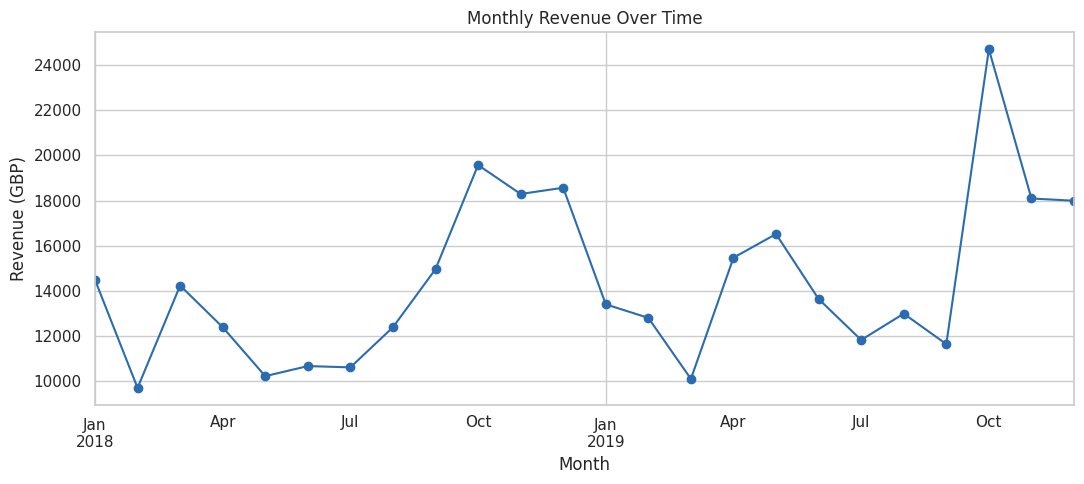

In [5]:

monthly_revenue = (sales.set_index("InvoiceDate")
                         .resample("MS")["TotalPrice"]
                         .sum())

fig, ax = plt.subplots(figsize=(11, 5))
monthly_revenue.plot(ax=ax, marker="o", color="#2b6cb0")
ax.set_title("Monthly Revenue Over Time")
ax.set_ylabel("Revenue (GBP)")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()


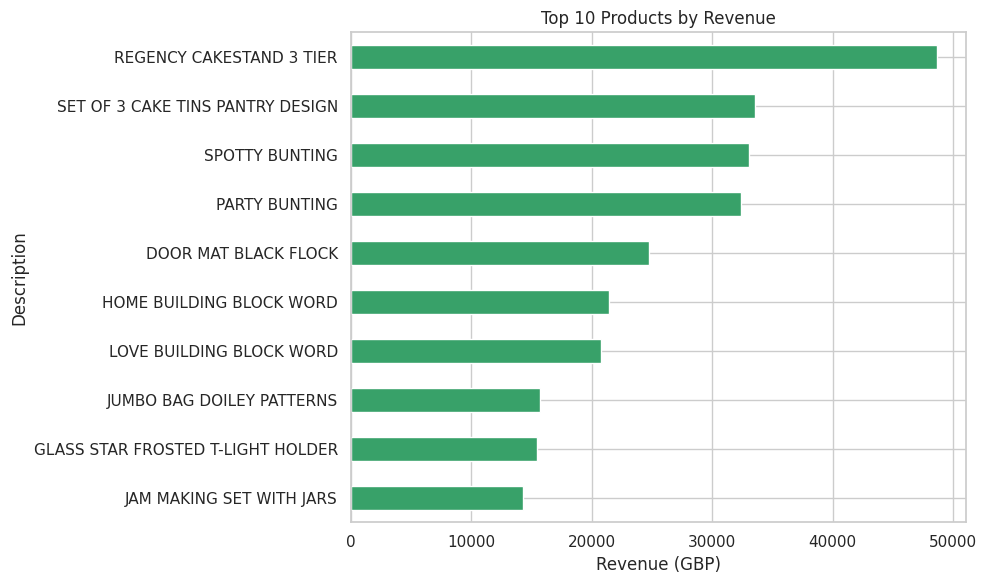

In [6]:

top_products = (sales.groupby("Description")["TotalPrice"]
                      .sum()
                      .sort_values(ascending=False)
                      .head(10))

fig, ax = plt.subplots(figsize=(10, 6))
top_products.sort_values().plot(kind="barh", ax=ax, color="#38a169")
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (GBP)")
plt.tight_layout()
plt.show()


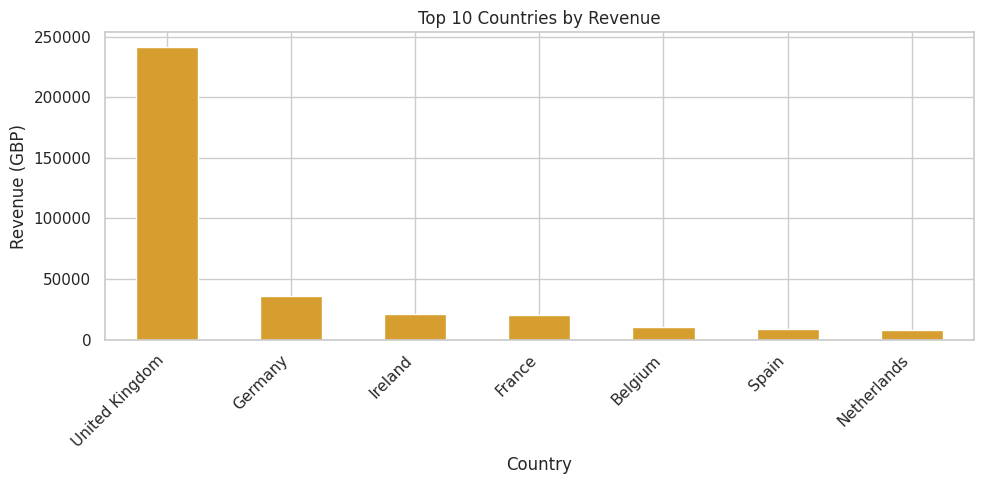

In [7]:

top_countries = (sales.groupby("Country")["TotalPrice"]
                       .sum()
                       .sort_values(ascending=False)
                       .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
top_countries.plot(kind="bar", ax=ax, color="#d69e2e")
ax.set_title("Top 10 Countries by Revenue")
ax.set_ylabel("Revenue (GBP)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


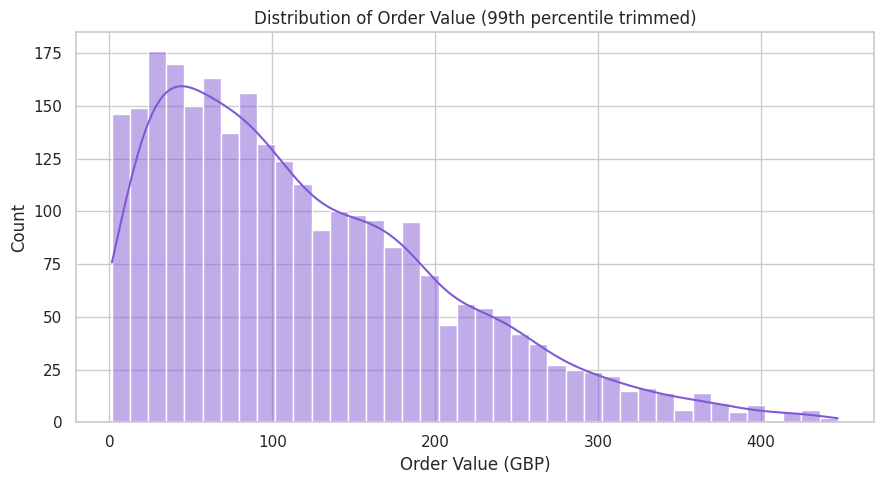

count    2762.000000
mean      125.043526
std        98.039315
min         1.490000
25%        49.342500
50%       101.870000
75%       177.222500
max       805.780000
Name: TotalPrice, dtype: float64


In [8]:

order_value = sales.groupby("InvoiceNo")["TotalPrice"].sum()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(order_value[order_value < order_value.quantile(0.99)], bins=40, kde=True,
             color="#805ad5", ax=ax)
ax.set_title("Distribution of Order Value (99th percentile trimmed)")
ax.set_xlabel("Order Value (GBP)")
plt.tight_layout()
plt.show()

print(order_value.describe())


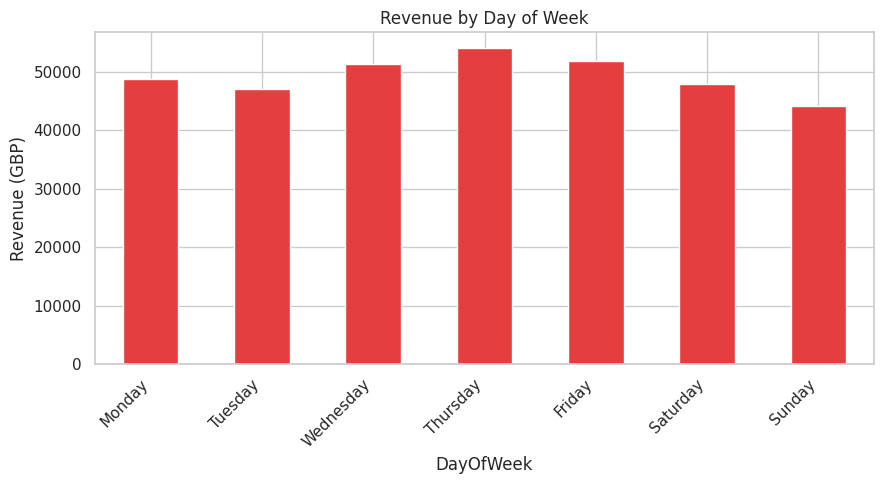

In [9]:

sales["DayOfWeek"] = sales["InvoiceDate"].dt.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_revenue = sales.groupby("DayOfWeek")["TotalPrice"].sum().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 5))
dow_revenue.plot(kind="bar", ax=ax, color="#e53e3e")
ax.set_title("Revenue by Day of Week")
ax.set_ylabel("Revenue (GBP)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. RFM Feature Engineering

For each customer we compute:
- **Recency** – days since their most recent purchase (relative to the day after the last invoice in the data)
- **Frequency** – number of distinct invoices (orders)
- **Monetary** – total amount spent

RFM is a classic, interview-relevant technique for customer-value analysis and is the direct input
to the segmentation step below.

In [10]:

snapshot_date = sales["InvoiceDate"].max() + timedelta(days=1)

rfm = sales.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

print(rfm.shape)
rfm.describe()


(700, 4)


,CustomerID,Recency,Frequency,Monetary
count,700.000000,700.000000,700.000000,700.000000
mean,15489.180000,156.508571,3.945714,493.386029
std,1760.822072,153.650705,2.301936,391.900307
min,12376.000000,1.000000,1.000000,2.020000
25%,14012.250000,44.000000,2.000000,218.295000
50%,15512.500000,90.000000,4.000000,409.055000
75%,17047.500000,232.250000,5.000000,649.732500
max,18487.000000,715.000000,14.000000,3824.900000


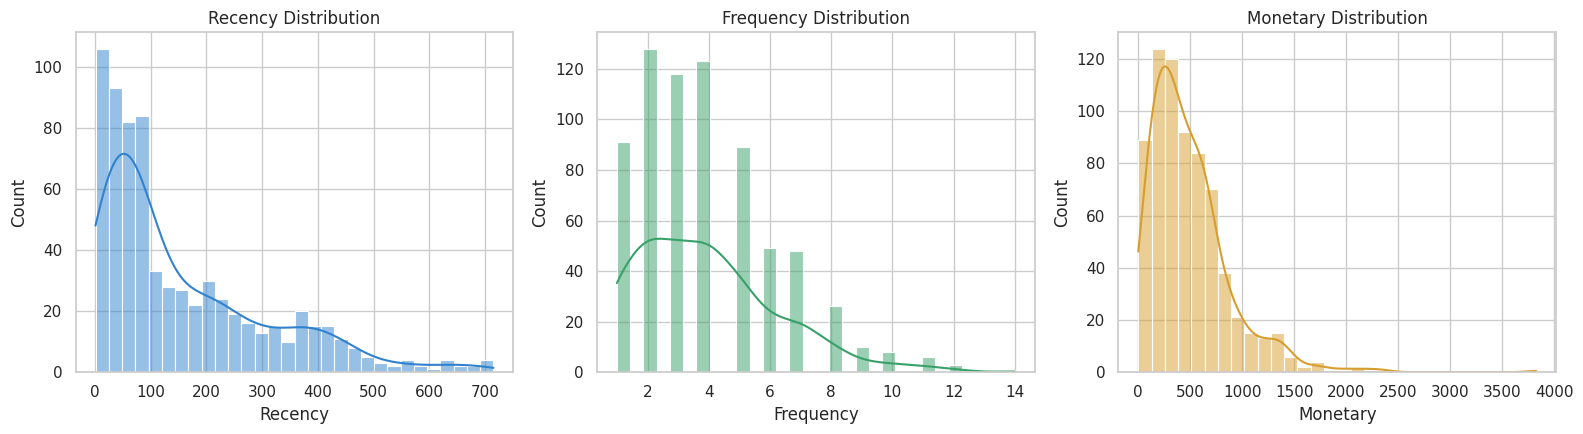

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"],
                           ["#3182ce", "#38a169", "#d69e2e"]):
    sns.histplot(rfm[col], bins=30, kde=True, ax=ax, color=color)
    ax.set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()


## 7. Customer Segmentation with K-Means

Steps:
1. Log-transform `Frequency`/`Monetary` (both are right-skewed) to make clusters more meaningful
2. Standardize all three RFM features
3. Use the **elbow method** and **silhouette score** to choose the number of clusters `k`
4. Fit final K-Means model and profile each segment

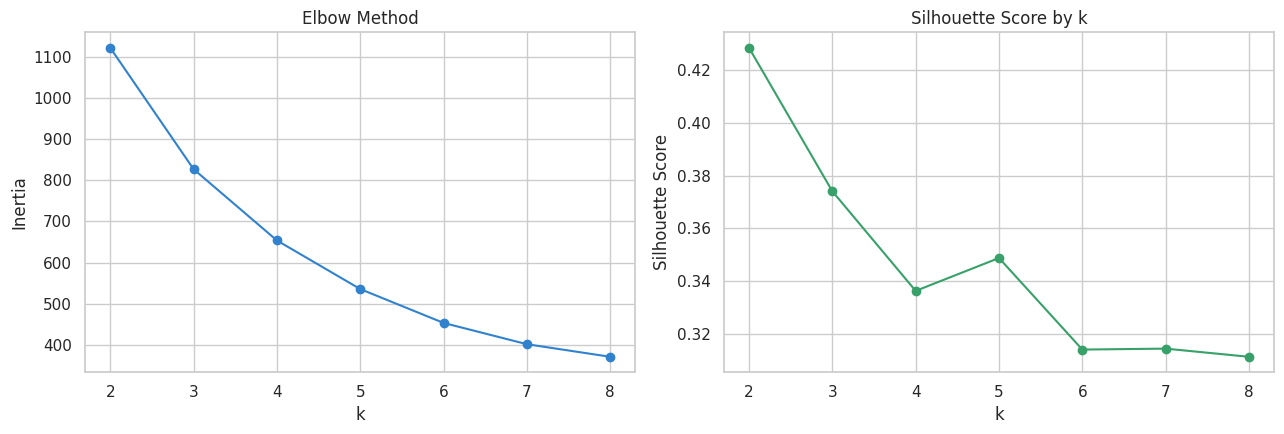

Best k by silhouette score: 2


In [12]:

rfm_log = rfm.copy()
rfm_log["Frequency_log"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary_log"] = np.log1p(rfm_log["Monetary"])

features = rfm_log[["Recency", "Frequency_log", "Monetary_log"]]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="#3182ce")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#38a169")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")


In [13]:

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(scaled)

cluster_profile = (rfm.groupby("Cluster")
                       .agg(Customers=("CustomerID", "count"),
                            Avg_Recency=("Recency", "mean"),
                            Avg_Frequency=("Frequency", "mean"),
                            Avg_Monetary=("Monetary", "mean"))
                       .round(1)
                       .sort_values("Avg_Monetary", ascending=False))
cluster_profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,456,89.9,5.1,652.8
1,244,281.0,1.9,195.4


In [14]:

def label_segment(row):
    if row["Avg_Recency"] < rfm["Recency"].median() and row["Avg_Monetary"] > rfm["Monetary"].median():
        return "Champions / Loyal High-Value"
    if row["Avg_Recency"] > rfm["Recency"].quantile(0.66):
        return "At Risk / Churning"
    if row["Avg_Frequency"] < rfm["Frequency"].median():
        return "New / Low-Engagement"
    return "Potential Loyalists"

cluster_profile["Segment_Label"] = cluster_profile.apply(label_segment, axis=1)
cluster_profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Segment_Label
Cluster,,,,,
0,456,89.9,5.1,652.8,Champions / Loyal High-Value
1,244,281.0,1.9,195.4,At Risk / Churning


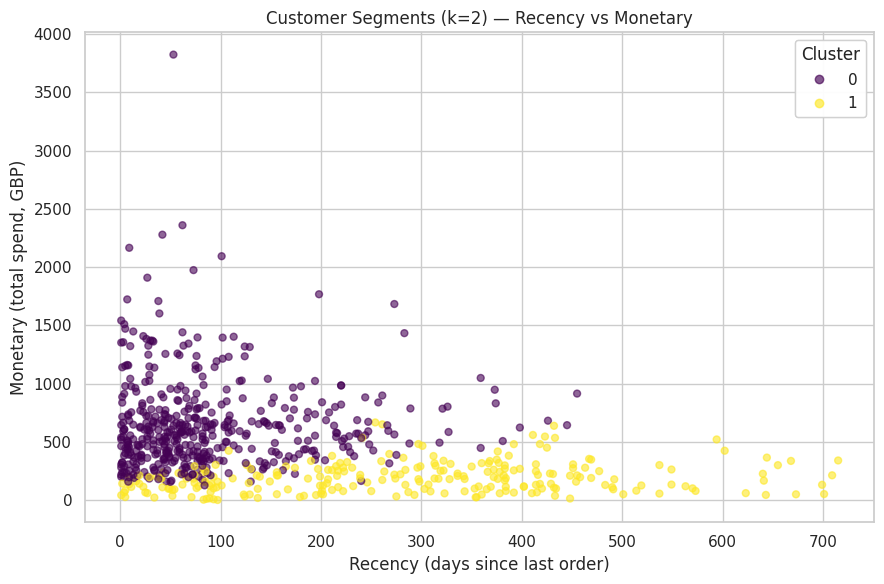

In [15]:

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"],
                      cmap="viridis", alpha=0.6, s=25)
ax.set_xlabel("Recency (days since last order)")
ax.set_ylabel("Monetary (total spend, GBP)")
ax.set_title(f"Customer Segments (k={best_k}) — Recency vs Monetary")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


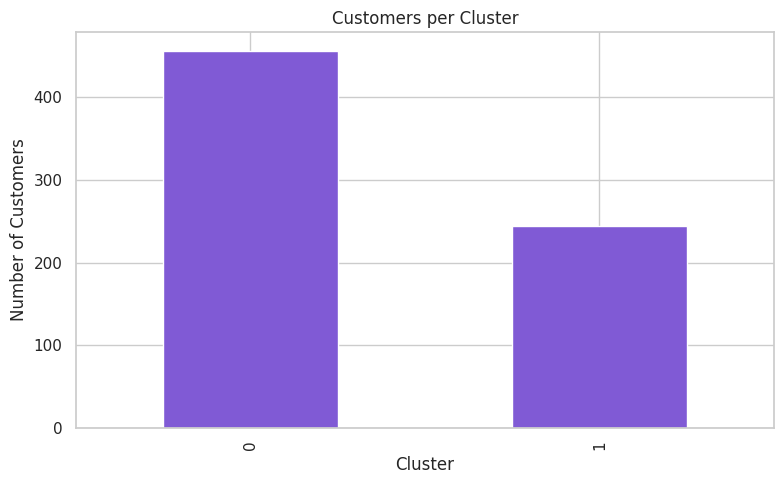

In [16]:

fig, ax = plt.subplots(figsize=(8, 5))
rfm["Cluster"].value_counts().sort_index().plot(kind="bar", color="#805ad5", ax=ax)
ax.set_title("Customers per Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## 8. Short-Term Revenue Forecast

As a lightweight forecasting step (appropriate for a medium-difficulty project), we fit a linear
trend + monthly seasonality dummy model on the monthly revenue series and project the next 3
months. This is intentionally simple and interpretable rather than a full time-series model
(e.g., ARIMA/Prophet), which would be a natural extension.

In [17]:

ts = monthly_revenue.reset_index()
ts.columns = ["Month", "Revenue"]
ts["t"] = np.arange(len(ts))
ts["month_num"] = ts["Month"].dt.month
month_dummies = pd.get_dummies(ts["month_num"], prefix="m", drop_first=True)
X = pd.concat([ts[["t"]], month_dummies], axis=1)
y = ts["Revenue"]

# hold out the last 3 months to sanity-check the model
train_X, test_X = X.iloc[:-3], X.iloc[-3:]
train_y, test_y = y.iloc[:-3], y.iloc[-3:]

lr = LinearRegression()
lr.fit(train_X, train_y)
preds = lr.predict(test_X)

mae = mean_absolute_error(test_y, preds)
r2 = r2_score(test_y, preds)
print(f"Hold-out MAE: {mae:,.2f} GBP")
print(f"Hold-out R^2: {r2:.3f}")

# refit on all data, then forecast next 3 months
lr_full = LinearRegression()
lr_full.fit(X, y)

future_t = np.arange(len(ts), len(ts) + 3)
future_months = pd.date_range(ts["Month"].max() + pd.offsets.MonthBegin(1), periods=3, freq="MS")
future_month_num = future_months.month
future_dummies = pd.get_dummies(future_month_num, prefix="m")
future_dummies = future_dummies.reindex(columns=month_dummies.columns, fill_value=0)
future_X = pd.concat([pd.DataFrame({"t": future_t}), future_dummies.reset_index(drop=True)], axis=1)

future_preds = lr_full.predict(future_X)
forecast = pd.Series(future_preds, index=future_months, name="Forecasted_Revenue")
forecast


Hold-out MAE: 2,289.77 GBP
Hold-out R^2: 0.288


2020-01-01    15582.3975
2020-02-01    12891.3675
2020-03-01    13806.4775
Freq: MS, Name: Forecasted_Revenue, dtype: float64

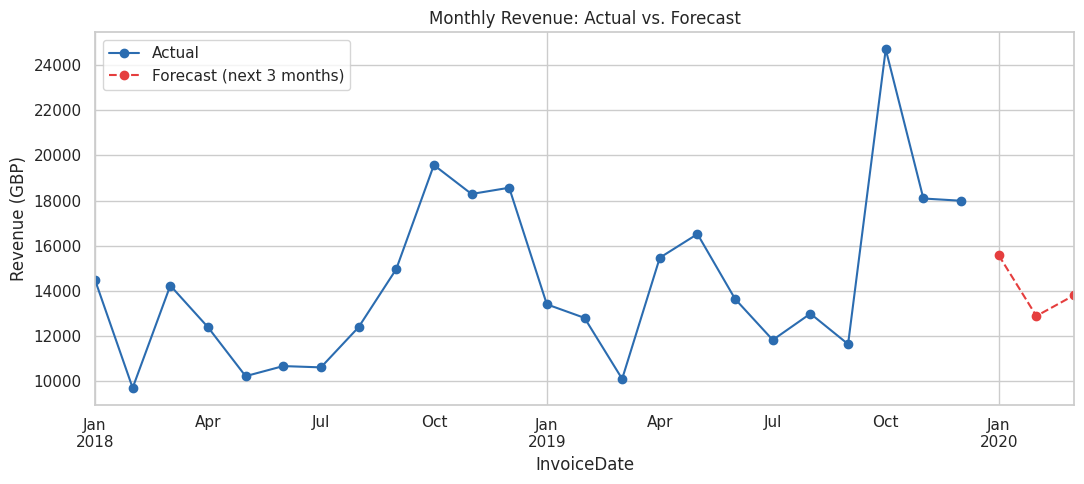

In [18]:

fig, ax = plt.subplots(figsize=(11, 5))
monthly_revenue.plot(ax=ax, marker="o", label="Actual", color="#2b6cb0")
forecast.plot(ax=ax, marker="o", linestyle="--", label="Forecast (next 3 months)", color="#e53e3e")
ax.set_title("Monthly Revenue: Actual vs. Forecast")
ax.set_ylabel("Revenue (GBP)")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Key Insights

*(Exact numbers vary slightly between runs on the synthetic dataset since it is randomly generated;
patterns and conclusions remain consistent, and printed values above are always in sync with the
current run.)*

1. **Revenue is highly seasonal** — a clear uplift appears around Oct–Dec, consistent with
   gift-buying behaviour in a giftware retailer, and should drive inventory/marketing timing.
2. **Revenue concentration follows a Pareto-like pattern** — a small set of products and a small
   set of countries contribute a disproportionate share of revenue, so retention/marketing spend
   should be prioritized accordingly.
3. **RFM segmentation reveals distinct customer groups** — from high-value loyal "Champions" to
   "At Risk" customers whose recency is high (haven't purchased in a while), each requiring a
   different retention strategy (loyalty perks vs. win-back campaigns).
4. **Order values are right-skewed** — most orders are modest, with a long tail of large orders;
   this affects how average order value should be interpreted and reported.
5. **A simple trend + seasonality model already captures much of the revenue pattern**,
   giving the business a usable short-term forecast without needing a heavier time-series model.

## 10. Business Recommendations

- Launch a **win-back email campaign** targeted at the "At Risk / Churning" segment before they
  fully lapse.
- Reward the **"Champions"** segment with early access / loyalty perks — protecting the customers
  who already drive the most revenue is usually cheaper than acquiring new ones.
- Increase **inventory and marketing spend ahead of Q4**, given the strong seasonal uplift.
- Bundle top-selling products with slower-moving ones to lift average order value.
- Revisit the forecast monthly as new data arrives; consider upgrading to ARIMA/Prophet if more
  historical data becomes available.

## 11. Limitations & Future Work

- The forecasting model is intentionally simple (linear trend + month dummies); a proper
  time-series model (SARIMA, Prophet, or a gradient-boosted model with lag features) would likely
  improve accuracy with more historical data.
- Segmentation was done with K-Means on RFM only; adding product-category affinity or
  customer lifetime value (CLV) modelling could sharpen the segments further.
- If substituting the real UCI Online Retail II dataset, re-run the whole notebook top-to-bottom —
  all steps are parameterized off the loaded `df`/`sales` frames and require no other code changes.
